In [8]:
import numpy
import numpy as np         # Numerical computations, arrays
import pandas
import pandas as pd        # Dataframes, tabular analysis
import matplotlib
import matplotlib.pyplot as plt   # Plotting and visualization
import seaborn
import seaborn as sns      # Statistical data visualization

print('matplotlib:', matplotlib.__version__)
print('numpy:', numpy.__version__)
print('pandas:', pandas.__version__)
print('seaborn:', seaborn.__version__)


matplotlib: 3.9.2
numpy: 1.26.4
pandas: 2.2.2
seaborn: 0.13.2


In [9]:
#Loading Airbnb open datasset
df = pd.read_csv("Airbnb_Open_Data.csv", encoding="utf-8", low_memory=False)
print("Dataset is loaded successfully")

Dataset is loaded successfully


In [10]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83412 entries, 0 to 102040
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              83412 non-null  int64  
 1   NAME                            83412 non-null  object 
 2   host id                         83412 non-null  int64  
 3   host_identity_verified          83412 non-null  object 
 4   host name                       83412 non-null  object 
 5   neighbourhood group             83412 non-null  object 
 6   neighbourhood                   83412 non-null  object 
 7   lat                             83412 non-null  float64
 8   long                            83412 non-null  float64
 9   country                         83412 non-null  object 
 10  country code                    83412 non-null  object 
 11  instant_bookable                83412 non-null  object 
 12  cancellation_policy             8341

In [28]:
print(df['price_$'].head())

0      $966 
1      $142 
4      $204 
5      $577 
7    $1,060 
Name: price_$, dtype: object


In [12]:
#Counting how much duplication of data in loaded datasset
df.duplicated().value_counts()

False    102058
True        541
Name: count, dtype: int64

In [15]:
#===>Data cleaning<===

#Drop duplicate records
df.drop_duplicates(inplace = True)

#Drop house_rules and license columns with insufficient data
cols_to_drop = [col for col in ['house_rules', 'license'] if col in df.columns]
df.drop(cols_to_drop, axis=1, inplace=True)

In [29]:
#Rename the price and service fee columns to include a dollar signs
df.rename(columns = {
    'price': 'price_$',
    'service fee': 'service fee_$'
}, inplace = True)


In [30]:
#Remove all dollar signs in the price and service fee columns
df['price_$'] = df['price_$'].str.replace('$', '', regex = False)
df['service fee_$'] = df['service fee_$'].str.replace('$', '', regex = False)

In [31]:
#Remove all commas from the price and service fee columns
df['price_$'] = df['price_$'].str.replace(',', '', regex=False)
df['service fee_$'] = df['service fee_$'].str.replace(',', '', regex = False)

In [33]:
#Drop all records with missing values
df.dropna(inplace = True)

#Change all mismatched data types to the appropriate data types
df['price_$'] = df['price_$'].astype(float)
df['service fee_$'] = df['service fee_$'].astype(float)
df['id'] = df['id'].astype(str)
df['host id'] = df['host id'].astype(str)
df['last review'] = pd.to_datetime(df['last review'], dayfirst=True)
df['Construction year'] = df['Construction year'].astype(int)

#Correct the spelling of 'brookln' to 'brooklyn'
df.loc[df['neighbourhood group'] == 'brookln', 'neighbourhood group'] = 'brooklyn'

#get rid of ouliers in the availability 365 column
df = df.drop(df[df['availability 365'] > 500].index)


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83411 entries, 0 to 102040
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              83411 non-null  object        
 1   NAME                            83411 non-null  object        
 2   host id                         83411 non-null  object        
 3   host_identity_verified          83411 non-null  object        
 4   host name                       83411 non-null  object        
 5   neighbourhood group             83411 non-null  object        
 6   neighbourhood                   83411 non-null  object        
 7   lat                             83411 non-null  float64       
 8   long                            83411 non-null  float64       
 9   country                         83411 non-null  object        
 10  country code                    83411 non-null  object        
 11  instan

In [35]:
#Counting how much duplication of data in loaded dataset
df.duplicated().value_counts()

False    83411
Name: count, dtype: int64

In [36]:
#EDA ===> EEXPLORATORY DATA ANALYSIS <===
df.describe()

,lat,long,Construction year,price_$,service fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,83411.000000,83411.000000,83411.000000,83411.000000,83411.000000,83411.000000,83411.000000,83411,83411.000000,83411.000000,83411.000000,83411.000000
mean,40.727353,-73.948500,2012.488509,626.212730,125.243709,7.405366,32.276642,2019-06-08 22:01:01.027922176,1.377584,3.278776,7.032682,141.742612
min,40.504560,-74.249840,2003.000000,50.000000,10.000000,-365.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.687650,-73.982110,2007.000000,340.000000,68.000000,2.000000,3.000000,2018-10-26 00:00:00,0.220000,2.000000,1.000000,6.000000
50%,40.721320,-73.953720,2012.000000,625.000000,125.000000,3.000000,11.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,101.000000
75%,40.762595,-73.930815,2017.000000,914.000000,183.000000,5.000000,38.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,266.000000
max,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,426.000000
std,0.056324,0.050347,5.760870,331.787179,66.360979,28.102221,51.957777,NaN,1.751041,1.283599,29.551590,133.368399


In [37]:
# Checking different property types in the dataset
property_types = df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,44163
Private room,37494
Shared room,1646
Hotel room,108


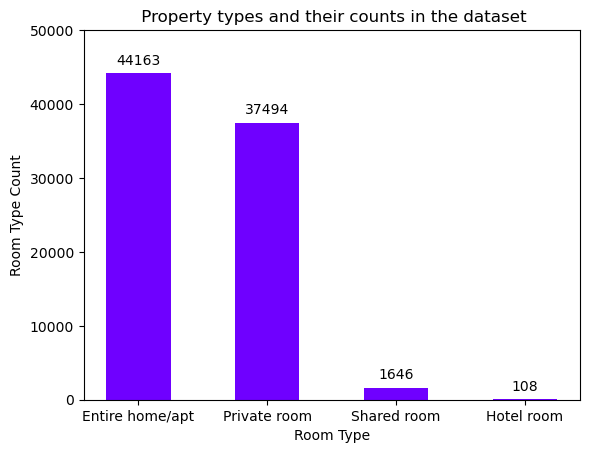

In [38]:
#Room type count plotted on a barchart
room_type_bar = plt.bar(property_types.index, property_types.loc[:, "count"], color = '#6F00FF', width=0.5);
plt.bar_label(room_type_bar, labels = property_types.loc[:, "count"], padding = 4);
plt.ylim([0, 50000]);
plt.xlabel('Room Type');
plt.ylabel('Room Type Count');
plt.title(' Property types and their counts in the dataset')
plt.savefig('Property_Types plot.png')

In [39]:
#Finding which neighboorhood group has highest number of listings
neighbourhood_group = df['neighbourhood group'].value_counts().to_frame()
neighbourhood_group

,count
neighbourhood group,
Brooklyn,34635
Manhattan,34566
Queens,11126
Bronx,2267
Staten Island,816
brooklyn,1


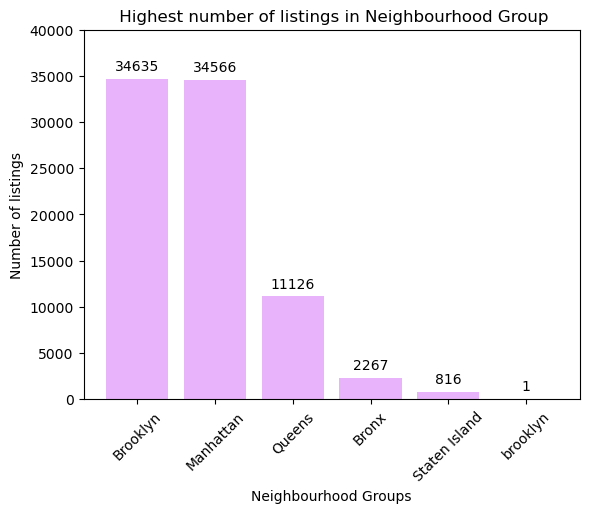

In [40]:
neighbourhood_group_bar = plt.bar(neighbourhood_group.index, neighbourhood_group.loc[:, "count"], color="#E9B3FB");
plt.bar_label(neighbourhood_group_bar, labels = neighbourhood_group.loc[:, "count"], padding = 4);
plt.ylim([0, 40000]);
plt.xlabel('Neighbourhood Groups');
plt.ylabel('Number of listings');
plt.xticks(rotation = 45);
plt.title(' Highest number of listings in Neighbourhood Group')
plt.savefig('Highest no.of ls in neighbourhood_group plot.png')

In [41]:
#Finding which neighboorhood group have the highest average prices for Airbhb listings 
avg_price = df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending = False).to_frame()
avg_price

,price_$
neighbourhood group,
Queens,630.457127
Bronx,630.201147
Brooklyn,627.438054
Manhattan,623.454869
Staten Island,622.132353
brooklyn,580.000000


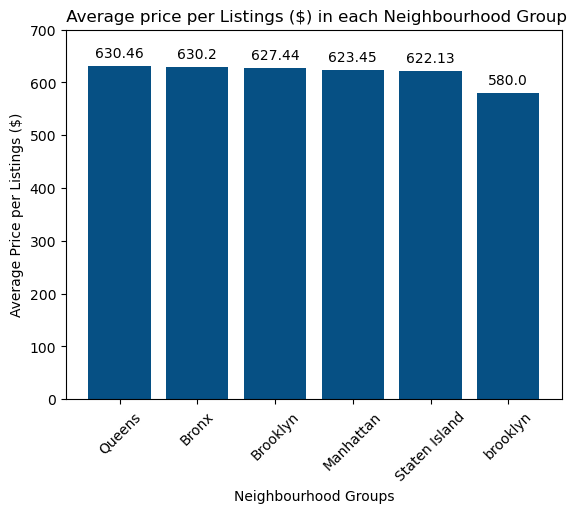

In [42]:
avg_price_bar = plt.bar(avg_price.index, avg_price.loc[:, 'price_$'], color="#065084");
plt.bar_label(avg_price_bar, labels = round(avg_price.loc[:, "price_$"], 2), label_type = 'edge', padding = 4);
plt.ylim([0, 700]);
plt.xlabel('Neighbourhood Groups');
plt.ylabel('Average Price per Listings ($)');
plt.xticks(rotation = 45);
plt.title(' Average price per Listings ($) in each Neighbourhood Group');
plt.savefig('Avg_price per listings plot.png');

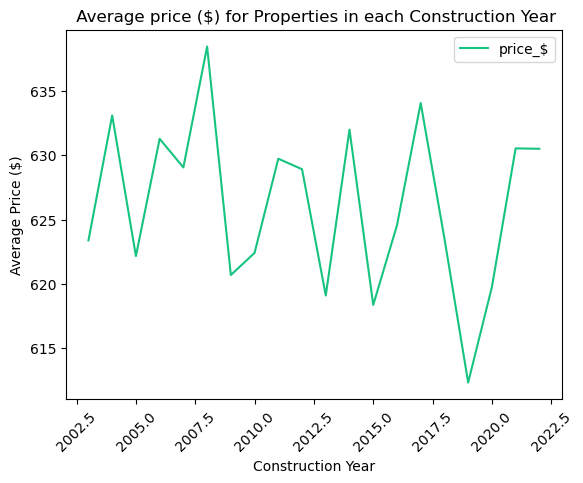

In [43]:
#Is there a relationship between the construction year of property and price
df.groupby(df['Construction year'])['price_$'].mean().to_frame().plot(color="#16C47F");
plt.xlabel('Construction Year');
plt.ylabel('Average Price ($)');
plt.xticks(rotation = 45);
plt.title(' Average price ($) for Properties in each Construction Year');
plt.savefig('Avg_price ($) for Properties in each Construction Year plot.png');

In [44]:
#Who are the top 10 hosts by calculated host listing count 
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending = False).nlargest(10).to_frame()
hosts

,calculated host listings count
host name,
Sonder (NYC),111921.0
Karen,42410.0
Jeniffer,31447.0
Blueground,21168.0
Kaz,17552.0
Corporate Housing,14833.0
Soya,10260.0
Stay With Vibe,10260.0
Kara,10092.0


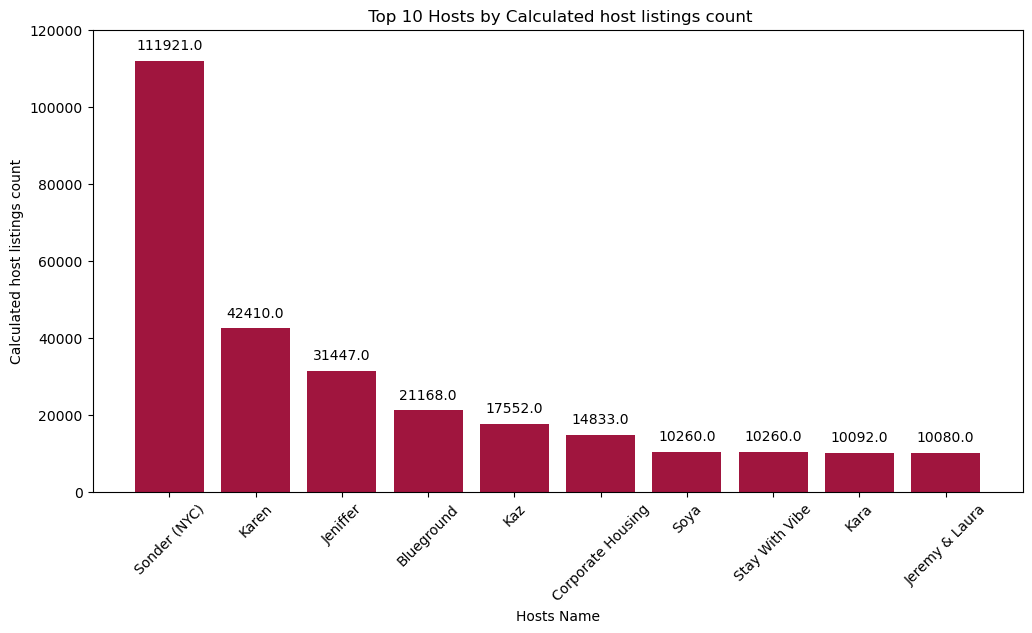

In [46]:
#Plotting Who are the top 10 hosts by calculated host listing count 
plt.figure(figsize=(12, 6))
hosts_bar = plt.bar(hosts.index, hosts.loc[:, 'calculated host listings count'], color="#A0153E", width=0.8);
plt.bar_label(hosts_bar, labels = hosts.loc[:, 'calculated host listings count'], label_type = 'edge', padding = 6);
plt.ylim([0, 120000]);
plt.xlabel('Hosts Name');
plt.ylabel('Calculated host listings count');
plt.xticks(rotation = 45);
plt.title(' Top 10 Hosts by Calculated host listings count');
plt.savefig('Top 10 Hosts plot.png');

In [47]:
#Are hosts with verified identitied more likely to receive positive reviews?
review = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending = False).to_frame()
review

,review rate number
host_identity_verified,
verified,3.284186
unconfirmed,3.273370


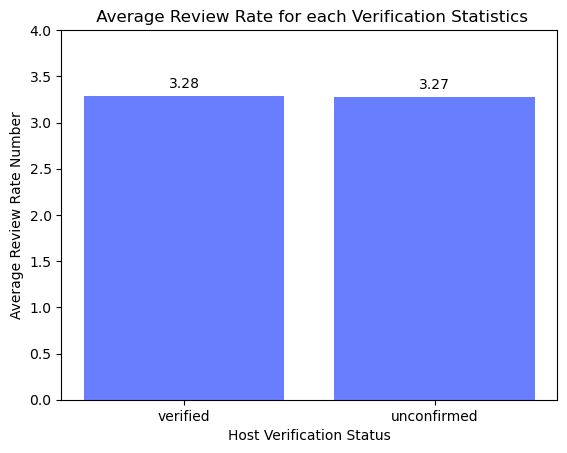

In [48]:
review_bar = plt.bar(review.index, review.loc[:, "review rate number"], color="#687EFF");
plt.bar_label(review_bar, labels = round(review.loc[:, "review rate number"], 2), padding =4);
plt.ylim([0, 4]);
plt.xlabel('Host Verification Status');
plt.ylabel('Average Review Rate Number');
plt.title(' Average Review Rate for each Verification Statistics');
plt.savefig('Avg Review Rate of Hosts.png');

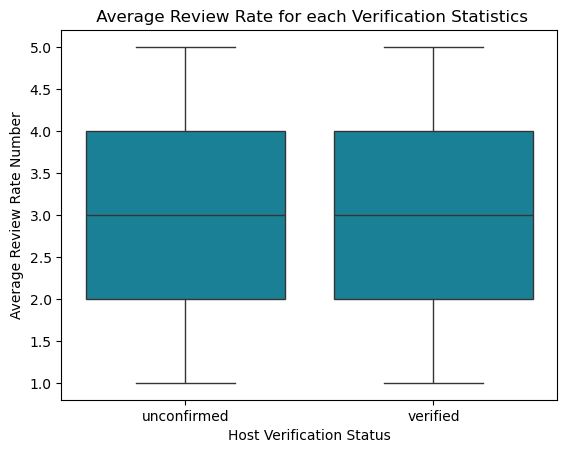

In [49]:
sns.boxplot(data =df, x="host_identity_verified", y="review rate number", color = "#068DA9")
plt.xlabel('Host Verification Status');
plt.ylabel('Average Review Rate Number');
plt.title(' Average Review Rate for each Verification Statistics');
plt.savefig('Avg Review Rate of Hosts_1.png');

In [50]:
#Is there a correlation between the price of a listing and its service fee
df['price_$'].corr(df['service fee_$'])

0.9999909074778258

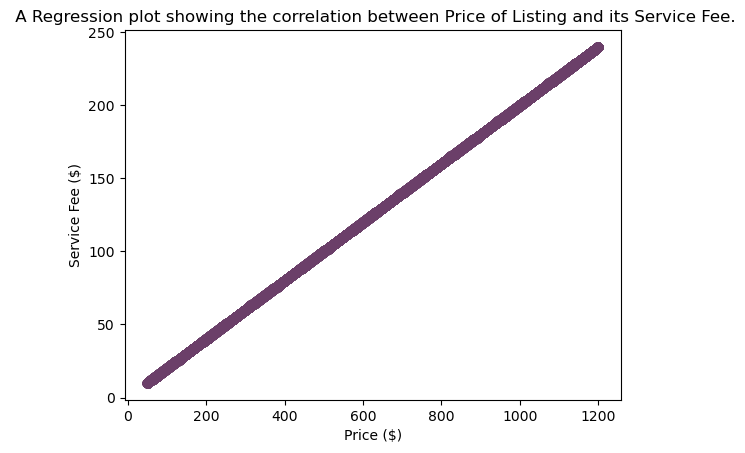

In [53]:
sns.regplot(df, x='price_$', y='service fee_$', color='#6B3F69')
plt.xlabel('Price ($)');
plt.ylabel('Service Fee ($)');
plt.title(' A Regression plot showing the correlation between Price of Listing and its Service Fee.');
plt.savefig('Corr of Price and Service Fee.png');

In [54]:
#What is the average review rate number(eg., stars) for listings, and does it vary based on the neighbourhood group and room types?
ARRN = df.groupby(['neighbourhood group', 'room type'])['review rate number'].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.381881
                    Private room               3.305810
                    Shared room                3.356322
Brooklyn            Entire home/apt            3.242491
                    Hotel room                 3.833333
                    Private room               3.274860
                    Shared room                3.323383
Manhattan           Entire home/apt            3.268846
                    Hotel room                 3.500000
                    Private room               3.285605
                    Shared room                3.261976
Queens              Entire home/apt            3.350045
                    Hotel room                 3.750000
                    Private room               3.310847
                    Shared room                3.327402
Staten Island       Entire home/apt            3.333333
                    Private room               3.497449
                    Shared room                3.714286
brooklyn            Private room               4.000000

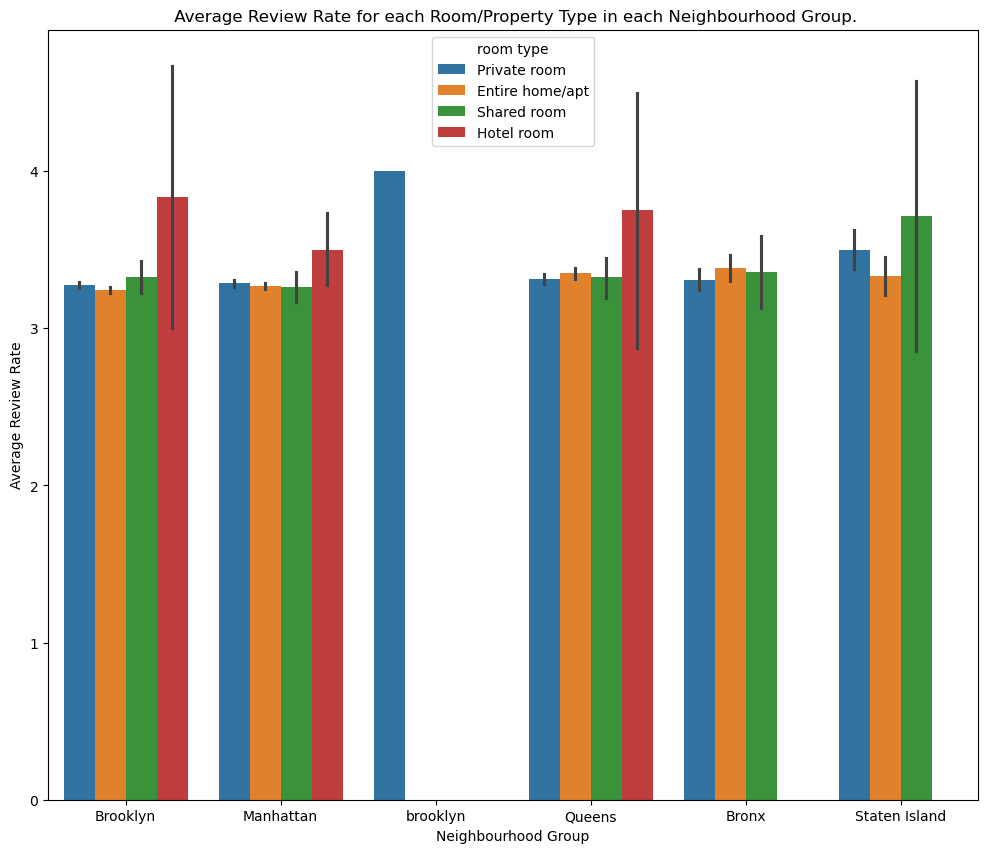

In [55]:
plt.figure(figsize = [12,10]);
sns.barplot(data = df, x='neighbourhood group', y='review rate number', hue='room type');
plt.xlabel('Neighbourhood Group');
plt.ylabel('Average Review Rate');
plt.title(' Average Review Rate for each Room/Property Type in each Neighbourhood Group.');
plt.savefig('Avg Review Rate for each room.png');

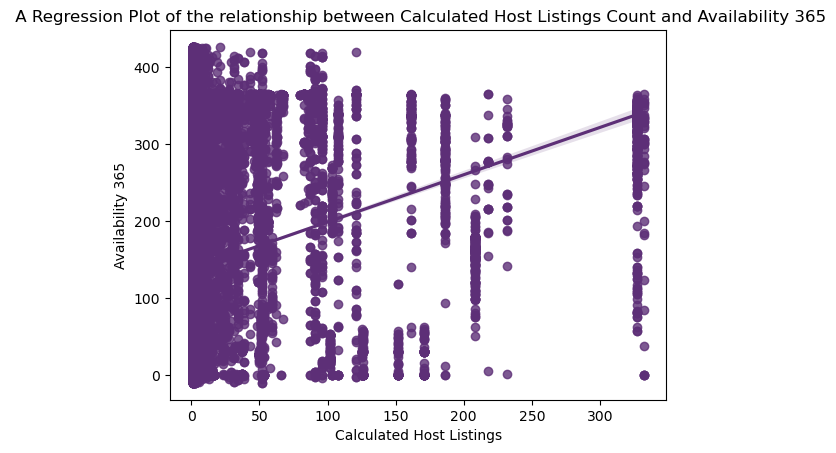

In [61]:
# Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?
sns.regplot(df, x='calculated host listings count', y='availability 365', color='#5D2F77');
plt.xlabel('Calculated Host Listings');
plt.ylabel('Availability 365');
plt.title(' A Regression Plot of the relationship between Calculated Host Listings Count and Availability 365');
plt.savefig('Calculated_Host_Listings_Count_and_Availability_365.png');